In [100]:
# Importamos librerías necesarias
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [101]:
# Cargamos el dataset
from google.colab import files
uploaded =files.upload()

Saving steam-200k.csv to steam-200k (2).csv


***1. Exploración de los datos***

In [102]:
# Definir la lista con los nombres de las columnas
nombres_columnas = ['ID', 'Juego', 'Comportamiento', 'Valor', 'Columna no relevante']

# Lee el archivo indicando que NO tiene encabezado (header=None)
# y asígnale los nombres
df = pd.read_csv('steam-200k.csv', header=None, names=nombres_columnas)

# 3. Guarda el nuevo archivo con los encabezados incluidos
df.to_csv('steam-200k_con_cabecera.csv', index=False)

In [103]:
df.head()

,ID,Juego,Comportamiento,Valor,Columna no relevante
0,151603712,The Elder Scrolls V Skyrim,purchase,1.0,0
1,151603712,The Elder Scrolls V Skyrim,play,273.0,0
2,151603712,Fallout 4,purchase,1.0,0
3,151603712,Fallout 4,play,87.0,0
4,151603712,Spore,purchase,1.0,0


In [104]:
df.shape

(200000, 5)

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    200000 non-null  int64  
 1   Juego                 200000 non-null  object 
 2   Comportamiento        200000 non-null  object 
 3   Valor                 200000 non-null  float64
 4   Columna no relevante  200000 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 7.6+ MB


In [106]:
# Valores nulos
display(df.isna().sum())

,0
ID,0
Juego,0
Comportamiento,0
Valor,0
Columna no relevante,0


In [107]:
print("Duplicados encontrados:", df.duplicated().sum())

Duplicados encontrados: 707


In [108]:
df.describe(include="all")

,ID,Juego,Comportamiento,Valor,Columna no relevante
count,2.000000e+05,200000,200000,200000.000000,200000.0
unique,NaN,5155,2,NaN,NaN
top,NaN,Dota 2,purchase,NaN,NaN
freq,NaN,9682,129511,NaN,NaN
mean,1.036559e+08,NaN,NaN,17.874384,0.0
std,7.208074e+07,NaN,NaN,138.056952,0.0
min,5.250000e+03,NaN,NaN,0.100000,0.0
25%,4.738420e+07,NaN,NaN,1.000000,0.0
50%,8.691201e+07,NaN,NaN,1.000000,0.0
75%,1.542309e+08,NaN,NaN,1.300000,0.0


### ***2. Preparación de los datos***

In [109]:
######## Eliminar filas duplicadas de registros completamente iguales

In [110]:
df = df.drop_duplicates()

In [111]:
print("Tamaño del dataset sin duplicados:", df.shape)

Tamaño del dataset sin duplicados: (199293, 5)


In [112]:
# eiminar columnas no importantes para el analisis porque no aporta ninguna informacion
df = df.drop(['Columna no relevante'], axis=1)

In [113]:
########## separar la columna de comportamiento

In [114]:
df = df.pivot_table(
    index=['ID', 'Juego'],
    columns='Comportamiento',
    values='Valor',
    aggfunc='sum'
).fillna(0).reset_index()

In [115]:
df.head()

Comportamiento,ID,Juego,play,purchase
0,5250,Alien Swarm,4.9,1.0
1,5250,Cities Skylines,144.0,1.0
2,5250,Counter-Strike,0.0,1.0
3,5250,Counter-Strike Source,0.0,1.0
4,5250,Day of Defeat,0.0,1.0


In [116]:
# Crear métricas agregadas por usuario
df = df.groupby('ID').agg(
    total_juegos_comprados=('purchase', 'sum'),
    total_horas_jugadas=('play', 'sum'),
    promedio_horas_por_juego=('play', 'mean'),
    juegos_probados=('play', lambda x: (x > 0).sum()) # Juegos donde jugó más de 0 horas
).reset_index()

# Porcentaje de biblioteca que realmente ha jugado
df['ratio_juego_compra'] = df['juegos_probados'] / df['total_juegos_comprados']

In [117]:
df.head()

,ID,total_juegos_comprados,total_horas_jugadas,promedio_horas_por_juego,juegos_probados,ratio_juego_compra
0,5250,21.0,225.5,10.738095,6,0.285714
1,76767,36.0,1227.0,34.083333,20,0.555556
2,86540,82.0,255.0,3.109756,15,0.182927
3,103360,10.0,0.0,0.000000,0,0.000000
4,144736,8.0,0.1,0.012500,1,0.125000


In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12393 entries, 0 to 12392
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        12393 non-null  int64  
 1   total_juegos_comprados    12393 non-null  float64
 2   total_horas_jugadas       12393 non-null  float64
 3   promedio_horas_por_juego  12393 non-null  float64
 4   juegos_probados           12393 non-null  int64  
 5   ratio_juego_compra        12393 non-null  float64
dtypes: float64(4), int64(2)
memory usage: 581.1 KB


In [119]:
df.describe(include="all")

,ID,total_juegos_comprados,total_horas_jugadas,promedio_horas_por_juego,juegos_probados,ratio_juego_compra
count,1.239300e+04,12393.000000,12393.000000,12393.000000,12393.000000,12393.000000
mean,1.611377e+08,10.393287,278.009021,55.471616,5.686839,0.726837
std,8.001490e+07,35.635890,760.270618,241.296617,17.078531,0.344795
min,5.250000e+03,1.000000,0.000000,0.000000,0.000000,0.000000
25%,9.706903e+07,1.000000,1.300000,0.833333,1.000000,0.500000
50%,1.649396e+08,2.000000,13.500000,5.676923,1.000000,1.000000
75%,2.209560e+08,6.000000,155.600000,27.500000,3.000000,1.000000
max,3.099031e+08,1068.000000,11754.000000,11754.000000,498.000000,1.000000


In [120]:
# Ahpra si la columna ID no es necesaria

In [121]:
# Usamos 4 variables sin el ratio ya que el nos va a dar la clasificacion

In [122]:
X =  df[["total_juegos_comprados", "total_horas_jugadas", "promedio_horas_por_juego", "juegos_probados"]]
y= df ["ratio_juego_compra"]

In [123]:
########## observar valores atipicos o muy grandes para estandarizar

In [124]:
# Escalamiento de datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

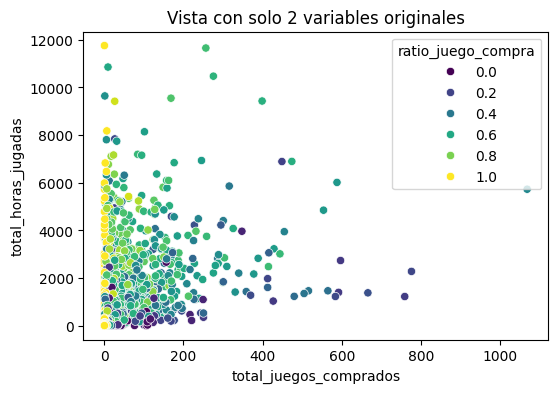

In [125]:
# Visualización original con solo dos variables
plt.figure(figsize=(6,4))
sns.scatterplot(x=X.iloc[:,0], y=X.iloc[:,1], hue= y , palette='viridis')
plt.title('Vista con solo 2 variables originales')
plt.xlabel('total_juegos_comprados')
plt.ylabel('total_horas_jugadas')
plt.show()

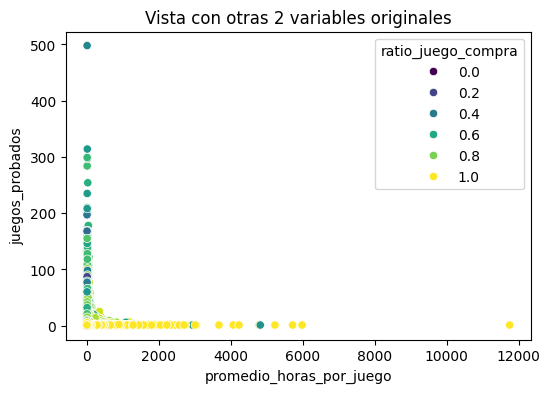

In [126]:
# Visualización original con solo dos variables
plt.figure(figsize=(6,4))
sns.scatterplot(x=X.iloc[:,2], y=X.iloc[:,3], hue= y , palette='viridis')
plt.title('Vista con otras 2 variables originales')
plt.xlabel('promedio_horas_por_juego')
plt.ylabel('juegos_probados')
plt.show()

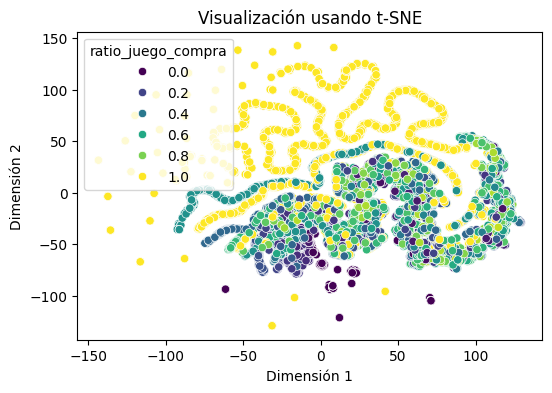

In [128]:
tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(6,4))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y, palette='viridis')
plt.title('Visualización usando t-SNE')
plt.xlabel('Dimensión 1')
plt.ylabel('Dimensión 2')
plt.show()

### ***3. Modelado***

In [129]:
# usaremos DBSCAN ya que mediante la graficacion identificacmos
#regiones irregulares aparentemete y ademas hay gran cantidad de
# outlayer que en las estadisticas se lograron identidficar
from sklearn.cluster import DBSCAN

In [130]:
X =  df[["total_juegos_comprados", "total_horas_jugadas", "promedio_horas_por_juego", "juegos_probados", "ratio_juego_compra"]]

In [131]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

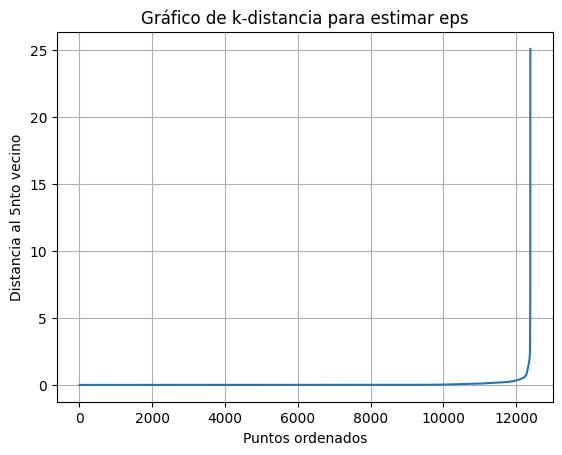

In [132]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 1])  # distancia al 2NDO vecino

plt.plot(distances)
plt.title('Gráfico de k-distancia para estimar eps')
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia al 5nto vecino')
plt.grid()
plt.show()

In [133]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
df["cluster"] = dbscan.fit_predict(X_scaled)

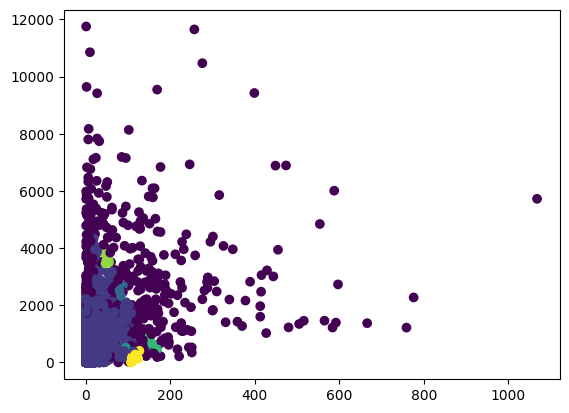

In [143]:
plt.scatter(
    df["total_juegos_comprados"],
    df["total_horas_jugadas"],
    c=df["cluster"],
    cmap="viridis"
)


### ***4. Interpretación de los clusters***

In [136]:
#Clientes en tabla

resumen = df.groupby("cluster").agg({
    "ID": "count",
    "total_juegos_comprados": ["mean"],
    "total_horas_jugadas": ["mean"],
    "promedio_horas_por_juego": ["mean"],
    "juegos_probados": ["mean"]
})

resumen.rename(columns={"total_juegos_comprados": "Promedio juegos comprados","total_horas_jugadas": "Promedio horas jugada", "juegos_probados": "Promedio juegos probados" }, inplace=True)
resumen

,ID,Promedio juegos comprados,Promedio horas jugada,promedio_horas_por_juego,Promedio juegos probados
,count,mean,mean,mean,mean
cluster,,,,,
-1,390,130.656410,3146.188718,380.672072,62.333333
0,11971,6.241250,181.590594,44.968404,3.769610
1,7,75.428571,2481.500000,33.367453,36.428571
2,5,86.600000,762.120000,8.904201,27.600000
3,5,155.400000,672.460000,4.384256,73.000000
4,5,49.800000,3585.480000,72.629355,36.800000
5,10,114.700000,206.040000,1.770776,9.900000



¿Qué caracteriza a los usuarios de este grupo?

- ***Muy activos:*** el grupo -1 o los outlayer son personas con muchos juegos comprados y muchas horas jugadas. Frecuentes
- ***Casual*** el grupo 0 son jugadores con pocos juegos comprados y pocas horas jugadas respecto a los demas. Ocacionales
- ***Activos:*** el grupo 1 son jugadores con medianamente demasiados juego comprados y demasiadas horas jugadas. Frecuentes
- ***Balanceado:*** 2,  medianamente demasidos juegoos comprados, y medianamente demasiadas horas jugadas. Medianamente frecuentes
-*** Compradores frecuentes:*** 3, Demasidos juegos comprados, medianamente horas jugadas. Medianamente frecuentes
- ***Dedicados:*** 4, medio bajo juegos comprados, demasiadas horas jugadas. Frecuentes
- ***Coleccionistas:*** 5, medio alto juegos comprados, pocas horas jugadas. Ocacionales




  A los muy activos les podriamos implementar una suscripcion de notificaciones para que esten enterados de nuevos juegos ya que estan siempre a la espera de nuevas experiencias. Al jugador casual, al que mas prioridad hay que darle, ya que son los que mas hay, darle ofertas de juegos y establecer campañas de subir de nivel con respecto al avance de los juegos y eso le implicaria mejores descuentos o inluso premios, para incentivarlos a jugar y fidelizarse. A los que son activos darles opciones de descuentos en las compras dentro de la app, si bien juegan varios titulos, tambien les dedican basntantes horas, asi que podrian darle descuentos dentro de juego para que pueda sacarle mas provecho. Balanceados, implementar promociones dentro de los juegos y tambien para comprar titulos. Dedicados, darles mucho mas descuentos dentro de los juegos, mejorar su exoeriencia de juego ofreciendoles compras dentro dentro de la app. Coleccionistas, notificaciones de titulos nuevos llamativos

- Qué información adicional sería útil para mejorar la segmentación?

    Ingresos de los jugadores, trabajo (independiente, asalariado, desempleado), tiempo libre

In [139]:
#Reduccion de dimensionalidad
tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X)

Text(0, 0.5, 'Componente principal 2')

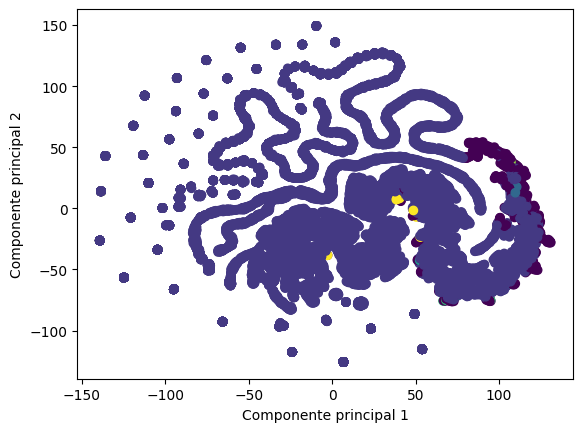

In [141]:
#Graficar
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=df["cluster"],
    cmap="viridis"
)
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")